Iter 0: melhor fitness = 0.004505, barras usadas = 221
Iter 10: melhor fitness = 0.004505, barras usadas = 221
Iter 20: melhor fitness = 0.004505, barras usadas = 221
Iter 30: melhor fitness = 0.004505, barras usadas = 221
Iter 40: melhor fitness = 0.004505, barras usadas = 221
Iter 50: melhor fitness = 0.004505, barras usadas = 221
Iter 60: melhor fitness = 0.004505, barras usadas = 221
Iter 70: melhor fitness = 0.004505, barras usadas = 221
Iter 80: melhor fitness = 0.004505, barras usadas = 221
Iter 90: melhor fitness = 0.004505, barras usadas = 221
Iter 99: melhor fitness = 0.004505, barras usadas = 221

=== MELHOR SOLUÇÃO FINAL ===
Fitness: 0.0045045045045045045
Barras usadas: 221


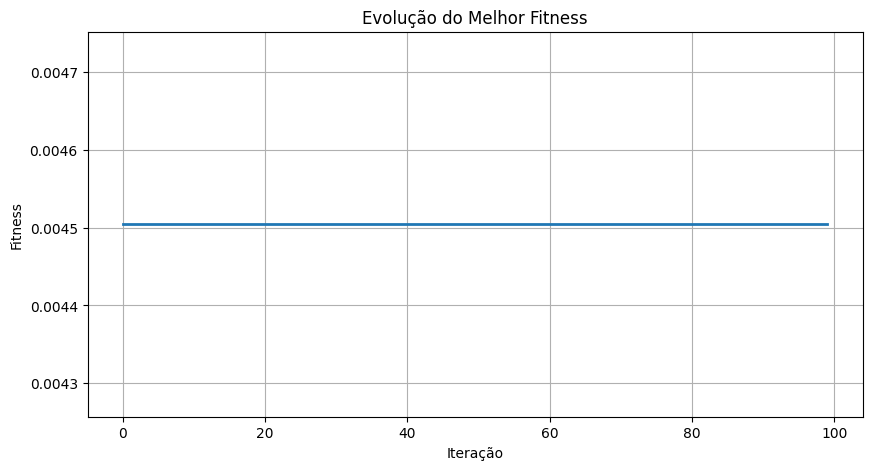

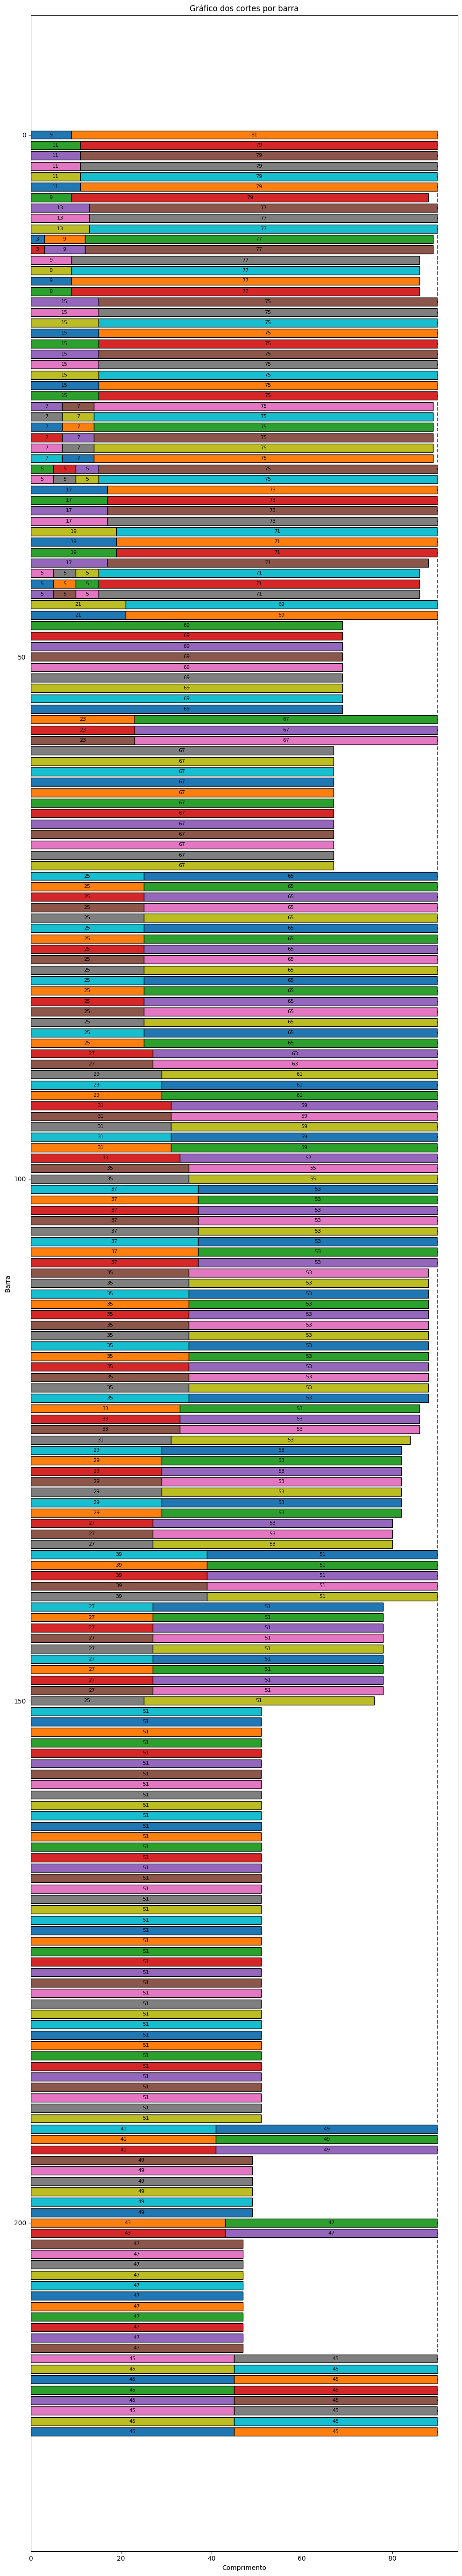

In [47]:
import random
import copy
from dataclasses import dataclass, field
from typing import List
import matplotlib.pyplot as plt
import numpy as np

random.seed(42)

@dataclass
class Individuo:
    genes: List[int] = field(default_factory=list)
    fitness: float = 0.0

class AlgoritmoGenetico:

    def __init__(self, tamPop, L, tamanhos, demandas, nBarras):
        self.tamPop = tamPop
        self.L = L
        self.tamanhos = tamanhos
        self.demandas = demandas
        self.nBarras = nBarras

        # cria lista expandida de itens
        self.items = []
        for i, d in enumerate(demandas):
            self.items += [i] * d

        self.numGenes = len(self.items)

        # Seleção
        self.pElite = 0.15
        self.pTorneio = 0.5 - self.pElite

        # Histórico para gráfico
        self.historico_fitness = []

    # ============================================================
    def execute(self, iter=10000):
        # inicializa com heurística gulosa (população válida)
        pop = self.inicializaPopulacaoB()

        for it in range(iter):
            novaPop = []

            # Elite
            numElite = max(1, int(self.pElite * self.tamPop))
            popOrdenada = sorted(pop, key=lambda x: x.fitness, reverse=True)
            elite = copy.deepcopy(popOrdenada[:numElite])
            novaPop.extend(elite)

            # Cruzamento + mutação + reparo
            while len(novaPop) < self.tamPop:
                pais = self.selecao(pop)
                filho = self.cruzamento(pais)
                self.mutacao(filho)
                self.reparar(filho)
                self.fitness(filho)
                novaPop.append(filho)

            pop = novaPop

            melhor = max(pop, key=lambda x: x.fitness)
            self.historico_fitness.append(melhor.fitness)

            # impressão resumida por iteração
            if (it % 10 == 0) or (it == iter - 1):
                print(f"Iter {it}: melhor fitness = {melhor.fitness:.6f}, barras usadas = {self.conta_barras_usadas(melhor)}")

        print("\n=== MELHOR SOLUÇÃO FINAL ===")
        melhor = max(pop, key=lambda x: x.fitness)
        print("Fitness:", melhor.fitness)
        print("Barras usadas:", self.conta_barras_usadas(melhor))
        # print("Genes:", melhor.genes)

        # Gera gráficos
        self.plot_fitness()
        self.plot_cortes(melhor)

        return melhor

    def gera_individuo_guloso(self):
        # cria vetor genes vazio
        genes = [-1] * self.numGenes

        # itens como pares (tamanho, idx_no_vetor_original)
        itens = [(self.tamanhos[self.items[i]], i) for i in range(self.numGenes)]

        # ordena por tamanho descrescente
        itens.sort(reverse=True)

        consumo = [0] * self.nBarras

        for tam, pos in itens:
            # tenta colocar nas barras
            colocado = False
            for b in range(self.nBarras):
                if consumo[b] + tam <= self.L:
                    consumo[b] += tam
                    genes[pos] = b
                    colocado = True
                    break

            # se não colocou (teoricamente raro)
            if not colocado:
                # joga na primeira barra vazia
                for b in range(self.nBarras):
                    if consumo[b] == 0:
                        consumo[b] += tam
                        genes[pos] = b
                        break

        return Individuo(genes=genes)

    def inicializaPopulacaoA(self):
        pop = []
        for _ in range(self.tamPop):
            ind = Individuo()
            ind.genes = [random.randint(0, self.nBarras - 1) for _ in range(self.numGenes)]
            self.reparar(ind)
            self.fitness(ind)
            pop.append(ind)
        return pop
    
    # ============================================================
    def inicializaPopulacaoB(self):
        pop = []

        # --- Criar população inteira usando heurística gulosa simples ---
        for _ in range(self.tamPop):
            pop.append(self.gera_individuo_guloso())
        
        # Avaliar fitness
        for ind in pop:
            self.fitness(ind)

        return pop


    # ============================================================
    def fitness(self, ind: Individuo):
        consumo = [0] * self.nBarras

        for g, item in zip(ind.genes, self.items):
            consumo[g] += self.tamanhos[item]

        for c in consumo:
            if c > self.L:
                ind.fitness = 0.0
                return 0.0

        usadas = sum(1 for c in consumo if c > 0)
        ind.fitness = 1.0 / (1.0 + usadas)
        return ind.fitness

    # ============================================================
    def reparar(self, ind: Individuo):
        """Repara indivíduo movendo itens de barras sobrecarregadas para barras com espaço."""
        consumo = [0] * self.nBarras
        for g, item in zip(ind.genes, self.items):
            consumo[g] += self.tamanhos[item]

        # itera os índices dos genes e garante que nenhum consumo > L ao final
        for i, (g, item_idx) in enumerate(zip(ind.genes, self.items)):
            tam = self.tamanhos[item_idx]
            if consumo[g] > self.L:
                # retira da barra atual
                consumo[g] -= tam
                colocado = False
                # procura uma barra que comporte
                for b in range(self.nBarras):
                    if consumo[b] + tam <= self.L:
                        ind.genes[i] = b
                        consumo[b] += tam
                        colocado = True
                        break
                if not colocado:
                    # se não encontrou (muito improvável com nBarras grande), coloca na barra com menor uso
                    b = min(range(self.nBarras), key=lambda x: consumo[x])
                    ind.genes[i] = b
                    consumo[b] += tam
        return ind

    # ============================================================
    def conta_barras_usadas(self, ind):
        consumo = [0] * self.nBarras
        for g, it in zip(ind.genes, self.items):
            consumo[g] += self.tamanhos[it]
        return sum(1 for c in consumo if c > 0)


    # ============================================================
    def selecao(self, pop):
        popOrdenada = sorted(pop, key=lambda x: x.fitness, reverse=True)
        numElite = max(1, int(self.pElite * self.tamPop))
        elite = popOrdenada[:numElite]

        torneioTam = max(2, int(self.pTorneio * self.tamPop))
        torneio = random.sample(pop, torneioTam)
        vencedor = max(torneio, key=lambda x: x.fitness)

        return random.choice(elite), vencedor


    # ============================================================
    def cruzamento(self, pais):
        p = random.randint(1, self.numGenes - 1)
        filho = Individuo()
        filho.genes = pais[0].genes[:p] + pais[1].genes[p:]
        return filho


    # ============================================================
    def mutacao(self, ind, taxa=0.05):
        for i in range(len(ind.genes)):
            if random.random() < taxa:
                ind.genes[i] = random.randint(0, self.nBarras - 1)


    # ============================================================
    def plot_fitness(self):
        plt.figure(figsize=(10, 5))
        plt.plot(self.historico_fitness, linewidth=2)
        plt.title("Evolução do Melhor Fitness")
        plt.xlabel("Iteração")
        plt.ylabel("Fitness")
        plt.grid(True)
        plt.show()

    # ============================================================
    def plot_cortes(self, ind: Individuo):
        barras = [[] for _ in range(self.nBarras)]

        # agrupa cortes por barra
        for gene, item in zip(ind.genes, self.items):
            barras[gene].append(self.tamanhos[item])

        # remove barras vazias
        barras = [b for b in barras if len(b) > 0]

        n = len(barras)
        plt.figure(figsize=(10, max(6, n * 0.25)))

        for idx, barra in enumerate(barras):
            x = 0
            for tamanho in barra:
                plt.barh(idx, tamanho, left=x, edgecolor='black')
                plt.text(x + tamanho / 2, idx, f"{tamanho}", ha='center', va='center', fontsize=8)
                x += tamanho

            # linha limite
            plt.plot([self.L, self.L], [idx - 0.4, idx + 0.4], 'r--')

        plt.title("Gráfico dos cortes por barra")
        plt.xlabel("Comprimento")
        plt.ylabel("Barra")
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.show()


# ============================================================
# EXEMPLO DE EXECUÇÃO (cole e rode localmente)
# L = 60
# tamanhos = [11, 3, 20, 7, 25, 14, 1, 19, 6, 24, 9, 18, 4, 16, 22, 8, 12, 5, 27, 10, 21, 2, 26, 13, 23, 15, 17, 28, 29, 30]
# demandas = [10, 3, 2, 7, 5, 4, 100, 10, 6, 2, 9, 1, 4, 3, 2, 8, 5, 5, 2, 10, 2, 2, 26, 13, 3, 5, 7, 8, 9, 3]

L = 90
tamanhos = [
    3, 5, 7, 9, 11, 13, 15, 17, 19, 21,
    23, 25, 27, 29, 31, 33, 35, 37, 39, 41,
    43, 45, 47, 49, 51, 53, 55, 57, 59, 61,
    63, 65, 67, 69, 71, 73, 75, 77, 79, 81
]

demandas = [
     2, 15, 12, 8, 5, 3, 10, 5, 3, 2,
     3, 18, 14, 10, 6, 4, 15, 8, 5, 3,
     2, 16, 13, 9, 55, 35, 2, 1, 5, 3,
     2, 17, 15, 11, 7, 4, 18, 9, 6, 1
]

# juntando tamanhos e demandas
pares = list(zip(tamanhos, demandas))

# ordenando pelo primeiro elemento (tamanho)
pares_ordenados = sorted(pares, key=lambda x: x[0])

# separando novamente
tamanhos_ordenados, demandas_ordenadas = zip(*pares_ordenados)

tamanhos_ordenados = list(tamanhos_ordenados)
demandas_ordenadas = list(demandas_ordenadas)
nBarras = 300

ga = AlgoritmoGenetico(
    tamPop=100,
    L=L,
    tamanhos=tamanhos_ordenados,
    demandas=demandas_ordenadas,
    nBarras=nBarras
)

melhor = ga.execute(iter=100)
